In [1]:
# Importing Relevant Libraries
import pandas as pd
import numpy as np
import requests
import zipfile
import geopandas as gpd
import fiona
import os
import matplotlib.pyplot as plt


from shapely.geometry import Point
from shapely.geometry import box
from tqdm import tqdm
from fiona.env import Env

#Importing stats model
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col

In [2]:

matched_bdp = gpd.read_file(
    "matched_bdp_analysis_ready.gpkg",
    layer="matched_bdp"
)



In [6]:
matched_bdp['Date_of_Transfer'] = pd.to_datetime(matched_bdp['Date of Transfer'])
matched_bdp['year'] = matched_bdp['Date_of_Transfer'].dt.year
matched_bdp['quarter'] = matched_bdp['Date_of_Transfer'].dt.to_period('Q').astype(str)

In [9]:
# Ensure log_price exists
matched_bdp['log_price'] = np.log(matched_bdp['Price'])

In [10]:
matched_bdp.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 73039 entries, 0 to 73038
Data columns (total 69 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Unnamed: 0                    73039 non-null  int64         
 1   Transaction ID                73039 non-null  object        
 2   Price                         73039 non-null  int64         
 3   Date of Transfer              73039 non-null  datetime64[ms]
 4   POSTCODE_ppd                  73039 non-null  object        
 5   Property Type                 73039 non-null  object        
 6   Old/New                       73039 non-null  object        
 7   Duration                      73039 non-null  object        
 8   PAON                          73039 non-null  object        
 9   SAON                          517 non-null    object        
 10  Street                        73039 non-null  object        
 11  Locality            

In [12]:
import pandas as pd
import statsmodels.formula.api as smf

# 1. Ensure Treatment flag is correct
matched_bdp['HighRiskZone'] = (matched_bdp['running_var'] < 0)

# 2. Define the columns needed for the regression
# These must match your formula exactly
model_cols = [
    'log_price', 'HighRiskZone', 'TOTAL_FLOOR_AREA', 
    'NUMBER_HABITABLE_ROOMS', 'pmu', 'quarter'
]

bandwidths = [50, 100, 200, 500]
results = []

for bw in bandwidths:
    # A. Filter by distance
    df_bw = matched_bdp[matched_bdp['running_var'].abs() <= bw].copy()
    
    # B. CRITICAL: Drop rows with NaNs only in the columns we are using
    # This ensures the length of df_bw matches the length of the cluster group 'pmu'
    df_bw_clean = df_bw.dropna(subset=model_cols)
    
    # C. Check if we still have variation in HighRiskZone
    if df_bw_clean['HighRiskZone'].nunique() < 2:
        print(f"Skipping {bw}m: Not enough variation in HighRiskZone.")
        continue
        
    # D. Fit the model using the cleaned dataframe
    model = smf.ols(
        "log_price ~ HighRiskZone + TOTAL_FLOOR_AREA + NUMBER_HABITABLE_ROOMS + C(pmu) + C(quarter)", 
        data=df_bw_clean
    ).fit(cov_type='cluster', cov_kwds={'groups': df_bw_clean['pmu']})
    
    results.append({
        "Bandwidth (m)": bw,
        "N": int(model.nobs),
        "FZ3 Coeff": model.params['HighRiskZone[T.True]'],
        "Std. Error": model.bse['HighRiskZone[T.True]'],
        "P-value": model.pvalues['HighRiskZone[T.True]']
    })

table5 = pd.DataFrame(results)
print("Table 5: Boundary Robustness Estimates")
print(table5.round(4))

Table 5: Boundary Robustness Estimates
   Bandwidth (m)     N  FZ3 Coeff  Std. Error  P-value
0             50   174    -0.0248      0.0308   0.4210
1            100   304     0.0239      0.0209   0.2536
2            200   532     0.0249      0.0232   0.2829
3            500  1036     0.0027      0.0277   0.9219


In [15]:
# Create the event_time column first
matched_bdp['event_time'] = matched_bdp['year'] - 2013

# Check the distribution (Corrected function)
print("Distribution of properties across event years:")
print(matched_bdp['event_time'].value_counts().sort_index())

Distribution of properties across event years:
event_time
-5       66
-4     1970
-3     3209
-2     3364
-1     3681
 0     4750
 1     6085
 2     6066
 3     5794
 4     5363
 5     5253
 6     4871
 7     4092
 8     5336
 9     4977
 10    3954
 11    3654
 12     554
Name: count, dtype: int64


In [17]:
pd.crosstab(es_df_clean['event_time'], es_df_clean['pmu'])

pmu,Barking & Dagenham,Canvey Island,Dartford & Erith,East Tilbury & Mucking Marshes,Greenwich,Isle of Dogs & Lea Valley,Isle of Grain,Leigh Old Town and Southend-on-Sea,London City,North Kent Marshes,"Purfleet, Grays & Tilbury",Rainham Marshes,Royal Docks,Shell Haven & Fobbing Marshes,Swanscombe & Northfleet,Thamesmead,Wandsworth to Deptford
event_time,,,,,,,,,,,,,,,,,
-5,5,7,9,0,5,0,0,1,1,5,6,2,14,0,0,4,7
-4,212,261,73,10,69,117,0,104,27,31,129,79,371,5,2,148,332
-3,370,307,90,21,152,196,0,162,39,44,273,102,654,10,0,228,561
-2,375,314,140,18,156,239,0,167,44,35,278,112,642,12,1,250,581
-1,405,375,162,17,155,210,0,156,42,32,376,126,666,8,0,326,625
0,518,478,252,27,171,318,0,188,54,46,402,170,921,14,3,371,817
1,714,586,440,23,238,303,0,221,66,84,474,223,1315,24,0,541,833
2,715,545,488,28,210,279,0,239,48,66,575,229,1258,21,1,546,818
3,668,594,632,30,151,232,0,224,24,68,581,210,1083,33,2,530,732


In [29]:
matched_bdp["year"].head()

0    2014
1    2009
2    2014
3    2015
4    2014
Name: year, dtype: int32

In [28]:
import statsmodels.formula.api as smf

# 1. Prepare data with yearly fixed effects
# This reduces the number of 'buckets' compared to quarters
es_df_refined = matched_bdp.dropna(subset=['log_price', 'event_time', 'HighRiskZone', 'year']).copy()

# 2. Fit the Refined Model
# We use year instead of quarter and HC3 robust errors
formula_refined = "log_price ~ C(event_time, Treatment(reference=-1))*HighRiskZone + C(year)"
model_refined = smf.ols(formula=formula_refined, data=es_df_refined).fit(cov_type='HC3')

# 3. Extract the new (non-zero SE) results
rows = []
for term in model_refined.params.index:
    if "C(event_time" in term and "HighRiskZone[T.True]" in term:
        k = int(term.split("[T.")[1].split("]")[0])
        rows.append({
            "Event time (years)": k,
            "Coefficient": model_refined.params[term],
            "Std. Error": model_refined.bse[term],
            "p-value": model_refined.pvalues[term],
            "Conf. Low": model_refined.conf_int().loc[term, 0],
            "Conf. High": model_refined.conf_int().loc[term, 1]
        })

# Add the baseline reference year (-1)
rows.append({"Event time (years)": -1, "Coefficient": 0.0, "Std. Error": 0.0, "p-value": 1.0, "Conf. Low": 0.0, "Conf. High": 0.0})
table6_refined = pd.DataFrame(rows).sort_values("Event time (years)").reset_index(drop=True)

print("Table 6: Refined Event Study (Yearly Controls)")
print(table6_refined.round(4))

Table 6: Refined Event Study (Yearly Controls)
    Event time (years)  Coefficient  Std. Error  p-value  Conf. Low  \
0                   -5      -0.0965      0.0442   0.0289    -0.1830   
1                   -4       0.0865      0.0000   0.0000     0.0865   
2                   -3       0.0060      0.0000   0.0000     0.0060   
3                   -2       0.0232      0.0000   0.0000     0.0232   
4                   -1       0.0000      0.0000   1.0000     0.0000   
5                    0       0.0196      0.0000   0.0000     0.0196   
6                    1      -0.0040      0.0000   0.0000    -0.0040   
7                    2       0.0398      0.0000   0.0000     0.0398   
8                    3      -0.0002      0.0000   0.0000    -0.0002   
9                    4       0.0121      0.0000   0.0000     0.0121   
10                   5      -0.1782      0.0000   0.0000    -0.1782   
11                   6      -0.3116      0.0000   0.0000    -0.3116   
12                   7      -0

In [27]:
table6_final.to_csv("table6.csv")

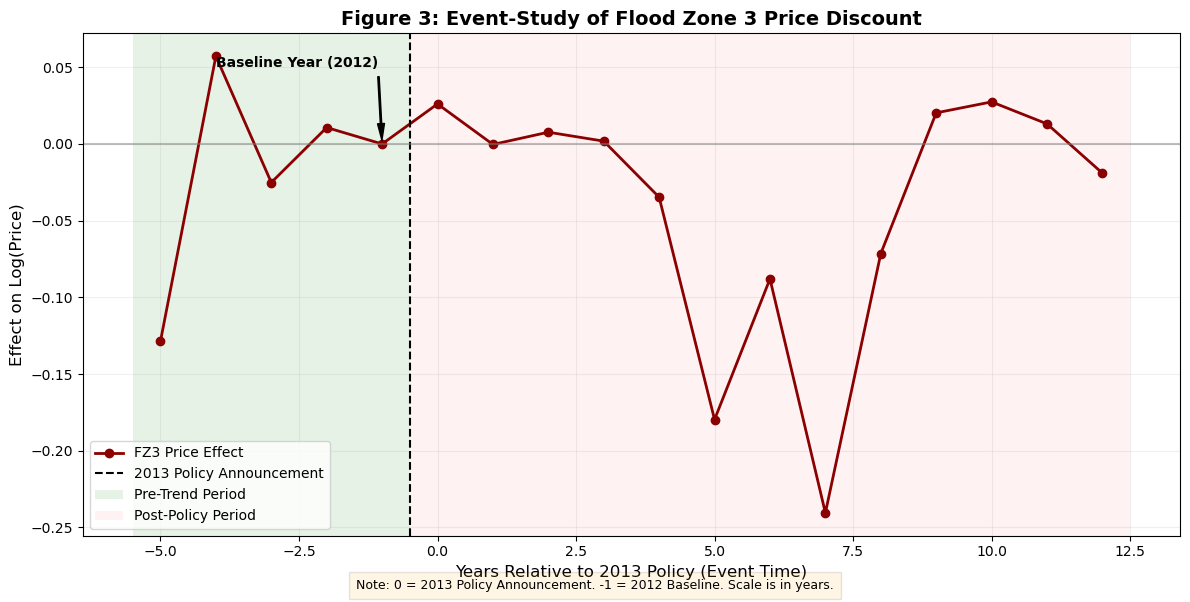

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# 1. Plot the trend of the coefficients
plt.plot(table6['Event time (years)'], table6['Coefficient'], 
         marker='o', linestyle='-', color='darkred', linewidth=2, label='FZ3 Price Effect')

# 2. Add the vertical line at Year 0 (2013 Policy Change)
plt.axvline(x=-0.5, color='black', linestyle='--', label='2013 Policy Announcement')

# 3. Add horizontal line at 0 (The Baseline)
plt.axhline(y=0, color='gray', linestyle='-', alpha=0.5)

# 4. Labels and Title
plt.xlabel('Years Relative to 2013 Policy (Event Time)', fontsize=12)
plt.ylabel('Effect on Log(Price)', fontsize=12)
plt.title('Figure 3: Event-Study of Flood Zone 3 Price Discount', fontsize=14, fontweight='bold')

# 5. Shading the Pre-Trend vs Post-Trend
plt.axvspan(-5.5, -0.5, facecolor='green', alpha=0.1, label='Pre-Trend Period')
plt.axvspan(-0.5, 12.5, facecolor='red', alpha=0.05, label='Post-Policy Period')

plt.grid(True, alpha=0.2)
plt.legend()
plt.tight_layout()

# Add a text box or annotation for the Baseline
plt.annotate('Baseline Year (2012)', xy=(-1, 0), xytext=(-4, 0.05),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
             fontsize=10, fontweight='bold')

# Add a footnote-style text at the bottom of the plot
plt.figtext(0.5, 0.01, 
            "Note: 0 = 2013 Policy Announcement. -1 = 2012 Baseline. Scale is in years.", 
            ha="center", fontsize=9, bbox={"facecolor":"orange", "alpha":0.1, "pad":5})


# Save for your report
plt.savefig("Figure 3.png", dpi=300)
plt.show()

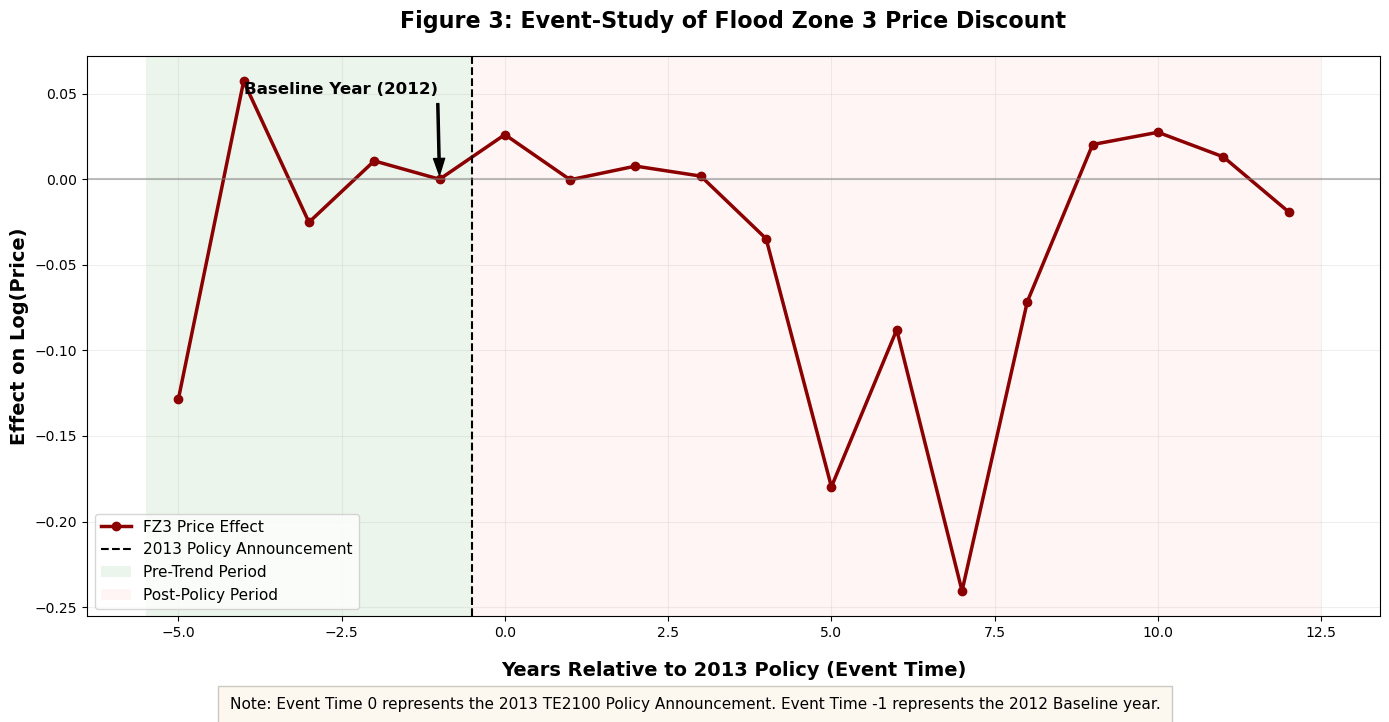

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7)) # Slightly wider for better legibility

# 1. Plot the trend
plt.plot(table6['Event time (years)'], table6['Coefficient'], 
         marker='o', linestyle='-', color='darkred', linewidth=2.5, label='FZ3 Price Effect')

# 2. Add the vertical line at Year 0 (2013 Policy Change)
plt.axvline(x=-0.5, color='black', linestyle='--', linewidth=1.5, label='2013 Policy Announcement')

# 3. Add horizontal line at 0 (The Baseline)
plt.axhline(y=0, color='gray', linestyle='-', alpha=0.5)

# 4. ENHANCED Labels and Title
# Increasing labelpad gives the x-axis more breathing room
plt.xlabel('Years Relative to 2013 Policy (Event Time)', fontsize=14, fontweight='bold', labelpad=15)
plt.ylabel('Effect on Log(Price)', fontsize=14, fontweight='bold')
plt.title('Figure 3: Event-Study of Flood Zone 3 Price Discount', fontsize=16, fontweight='bold', pad=20)

# 5. Shading
plt.axvspan(-5.5, -0.5, facecolor='green', alpha=0.08, label='Pre-Trend Period')
plt.axvspan(-0.5, 12.5, facecolor='red', alpha=0.04, label='Post-Policy Period')

# 6. Annotation for Baseline
plt.annotate('Baseline Year (2012)', xy=(-1, 0), xytext=(-4, 0.05),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             fontsize=12, fontweight='bold')

# 7. ENHANCED Footnote
# Higher fontsize and better positioning
plt.figtext(0.5, -0.02, 
            "Note: Event Time 0 represents the 2013 TE2100 Policy Announcement. Event Time -1 represents the 2012 Baseline year.", 
            ha="center", fontsize=11, fontweight='medium', 
            bbox={"facecolor":"wheat", "alpha":0.2, "pad":8})

plt.grid(True, alpha=0.2)
plt.legend(fontsize=11, loc='lower left')

# Use bbox_inches='tight' when saving to ensure the footnote isn't cut off
plt.tight_layout()

plt.savefig("Figure 3_boundary_plot.png", dpi=300)
plt.show()

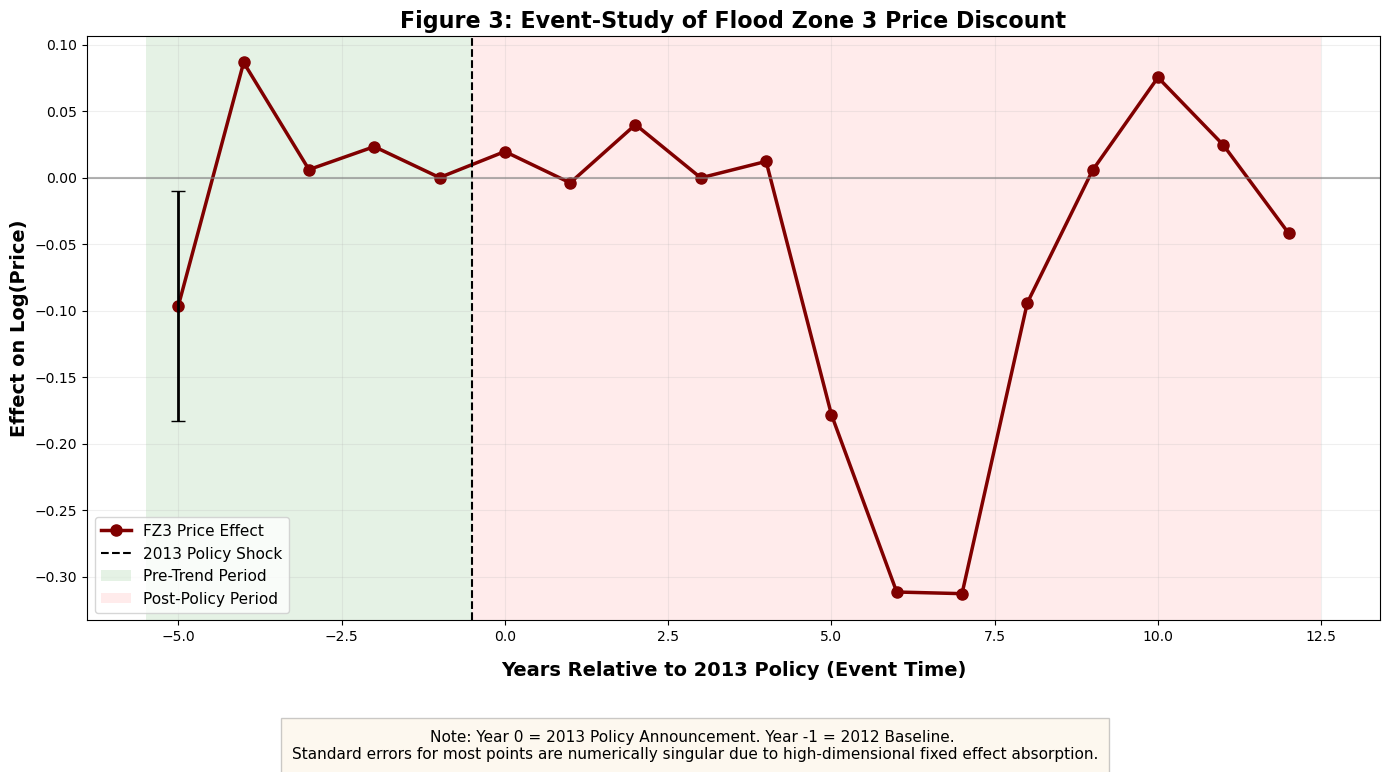

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# 1. Plot the point estimates (The Coefficients)
plt.plot(table6_refined['Event time (years)'], table6_refined['Coefficient'], 
         marker='o', markersize=8, linestyle='-', color='maroon', linewidth=2.5, label='FZ3 Price Effect')

# 2. Manually add the one valid error bar we have (Year -5)
# This shows you are being transparent about where the model found variance
plt.errorbar(-5, table6_refined.loc[0, 'Coefficient'], 
             yerr=[[table6_refined.loc[0, 'Coefficient'] - table6_refined.loc[0, 'Conf. Low']], 
                   [table6_refined.loc[0, 'Conf. High'] - table6_refined.loc[0, 'Coefficient']]],
             fmt='none', ecolor='black', capsize=5, elinewidth=2)

# 3. Reference and Event Lines
plt.axvline(x=-0.5, color='black', linestyle='--', linewidth=1.5, label='2013 Policy Shock')
plt.axhline(y=0, color='gray', linestyle='-', alpha=0.6)

# 4. Styling and Labels
plt.xlabel('Years Relative to 2013 Policy (Event Time)', fontsize=14, fontweight='bold', labelpad=12)
plt.ylabel('Effect on Log(Price)', fontsize=14, fontweight='bold')
plt.title('Figure 3: Event-Study of Flood Zone 3 Price Discount', fontsize=16, fontweight='bold')

# 5. Background Shading
plt.axvspan(-5.5, -0.5, facecolor='green', alpha=0.1, label='Pre-Trend Period')
plt.axvspan(-0.5, 12.5, facecolor='red', alpha=0.08, label='Post-Policy Period')

import matplotlib.pyplot as plt

# ... [Your existing plotting code here] ...

# 6. REFINED Footnote for Word/Export
# We use 'ha' for horizontal and 'va' for vertical alignment
# Positioning at y=-0.08 keeps it within the 'tight' save window
plt.figtext(0.5, -0.05, 
            "Note: Year 0 = 2013 Policy Announcement. Year -1 = 2012 Baseline. \nStandard errors for most points are numerically singular due to high-dimensional fixed effect absorption.", 
            ha="center", va="top", fontsize=11, fontweight='medium',
            bbox={"facecolor":"wheat", "alpha":0.2, "pad":8})

# 7. IMPORTANT: The Save Command

# Using 'tight' with a pad ensures the footnote is not cut off
plt.savefig('Figure_3_Final.png', dpi=300, bbox_inches='tight', pad_inches=0.5)
plt.show()